In [183]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [184]:
dataset=sns.load_dataset('titanic')
dataset.to_csv('titanic.csv',index=False)

Part A — Profiling, cleaning, and the data story

In [185]:
df=pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [186]:
print('Information of the dataset')
print('-'*60)
df.info()

print('Describing the Dataset')
print('-'*60)
print(df.describe(include='all'))

print('Shape of the Dataset')
print('-'*60)
print(df.shape)

print('percentage of missing values in every column')
print('-'*60)
missingpercentage=((df.isnull().sum()/len(df))*100).round(2)
missing=missingpercentage[missingpercentage>0]
print(missing)

Information of the dataset
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB
Describing the Dataset
-------------

In [187]:
from pandas.api.types import is_numeric_dtype
for i,j in missing.items():
  if j<5:
    df.dropna(subset=[i],inplace=True)
  elif (5<=j<=30):
    if is_numeric_dtype(df[i]):
      df[i] = df[i].fillna(df[i].median())
    else:
      df[i]=df[i].fillna(df[i].mode()[0])
  else:
    df.drop(columns=i,inplace=True)

Missing Value Handling

Age (19.87% missing): Since the missing percentage falls between 5% and 30%, the missing values were imputed using the median age. The median was chosen because it is less sensitive to extreme values than the mean.

Embarked (0.22% missing): The missing percentage is below 5%, so the rows containing missing values were removed. Only two rows were affected, making the impact on the dataset negligible.

Embark Town (0.22% missing): Similar to embarked, the missing percentage is below 5%, so the affected rows were removed.

Deck (77.22% missing): Since over 77% of the values were missing, imputing this column would not be reliable. Therefore, the deck column was dropped from the dataset.

In [188]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


Univariate analysis

In [189]:
import os

os.makedirs("charts", exist_ok=True)

AGE
Q1            : 22.00
Q3            : 35.00
IQR           : 13.00
Lower Bound   : 2.50
Upper Bound   : 54.50
Outlier Count : 65


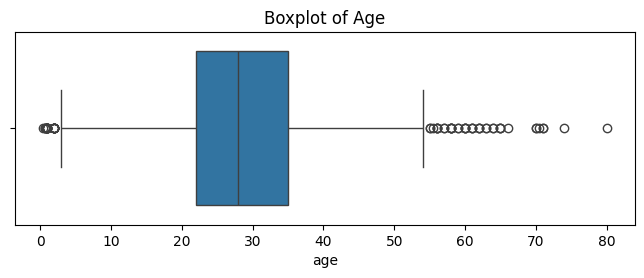

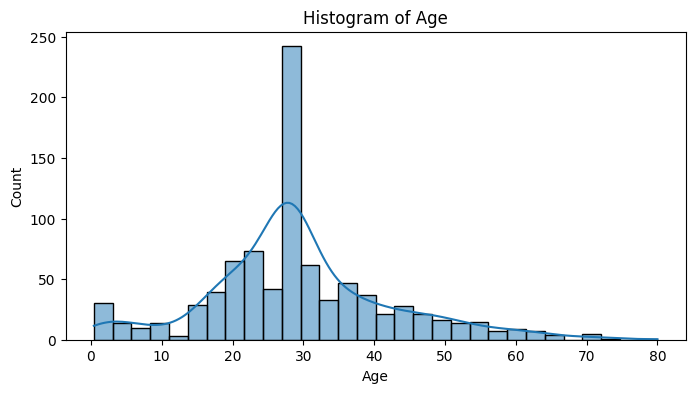

FARE
Q1            : 7.90
Q3            : 31.00
IQR           : 23.10
Lower Bound   : -26.76
Upper Bound   : 65.66
Outlier Count : 114


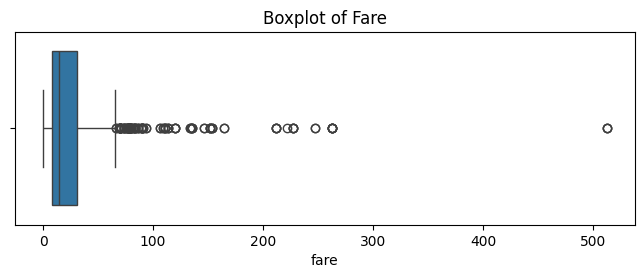

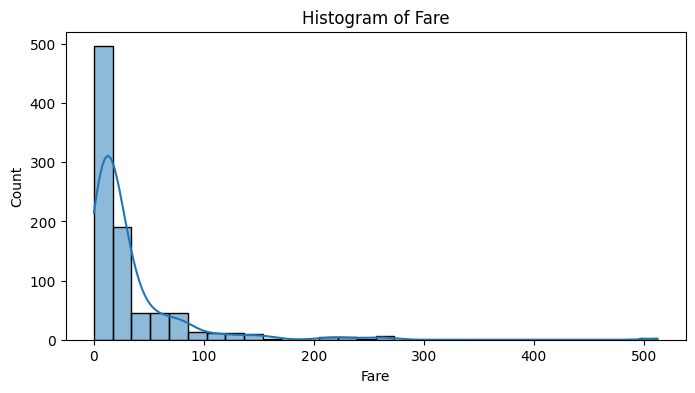

In [190]:
plotting = ['age', 'fare']

for col in plotting:
    # Calculate IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("=" * 50)
    print(f"{col.upper()}")
    print(f"Q1            : {Q1:.2f}")
    print(f"Q3            : {Q3:.2f}")
    print(f"IQR           : {IQR:.2f}")
    print(f"Lower Bound   : {lower:.2f}")
    print(f"Upper Bound   : {upper:.2f}")
    print(f"Outlier Count : {len(outliers)}")

    # Boxplot
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col.capitalize()}")
    plt.savefig(f"charts/{col}_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Histogram
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.savefig(f"charts/{col}_histogram.png", dpi=300, bbox_inches="tight")
    plt.show()

Outlier Handling:

Outliers were identified using the IQR method but were retained because they represent valid passenger information rather than data entry errors. In particular, high fare values correspond to genuine first-class tickets, so removing them could discard meaningful information.

In [191]:
print(f"Mean of fare is {df['fare'].mean()}")
print(f"Median of fare is {df['fare'].median()}")
print(f"Mode of fare is {df['fare'].mode()[0]}")

Mean of fare is 32.09668087739032
Median of fare is 14.4542
Mode of fare is 8.05


For fare:

Mean > Median > Mode

Therefore, the fare distribution is right-skewed (positively skewed).

The mean is higher than the median because a small number of passengers
paid very high fares, creating a long right tail.
Mean > Median > Mode → Right-skewed
Mean < Median < Mode → Left-skewed
Mean ≈ Median ≈ Mode → Symmetric

Bivariate Analysis


In [192]:
df['pclass'].unique()

array([3, 1, 2])

In [193]:
first=df[df['pclass']==1]
second=df[df['pclass']==2]
third=df[df['pclass']==3]
print("first class survival rate:", round(first['survived'].mean()*100,2))
print("second class survival rate:", round(second['survived'].mean()*100,2))
print("Third class survival rate:", round(third['survived'].mean()*100,2))

first class survival rate: 62.62
second class survival rate: 47.28
Third class survival rate: 24.24


In [194]:
# Overall
print(f"Overall Survival Rate: {df['survived'].mean()*100:.2f}%")

# By gender
survival_by_gender = round(df.groupby("sex")["survived"].mean() * 100,2)

print("\nSurvival Rate by Gender")
print(survival_by_gender)

Overall Survival Rate: 38.25%

Survival Rate by Gender
sex
female    74.04
male      18.89
Name: survived, dtype: float64


In [195]:
combinations=[("female",1),("male",1),
              ("female",2),("male",2),
              ("female",3),("male",3)]

for sex, pclass in combinations:
    subset = df[(df['sex'] == sex) & (df['pclass'] == pclass)]

    print(sex, "class", pclass,
          "survival rate:", round(subset['survived'].mean()*100,2))

female class 1 survival rate: 96.74
male class 1 survival rate: 36.89
female class 2 survival rate: 92.11
male class 2 survival rate: 15.74
female class 3 survival rate: 50.0
male class 3 survival rate: 13.54


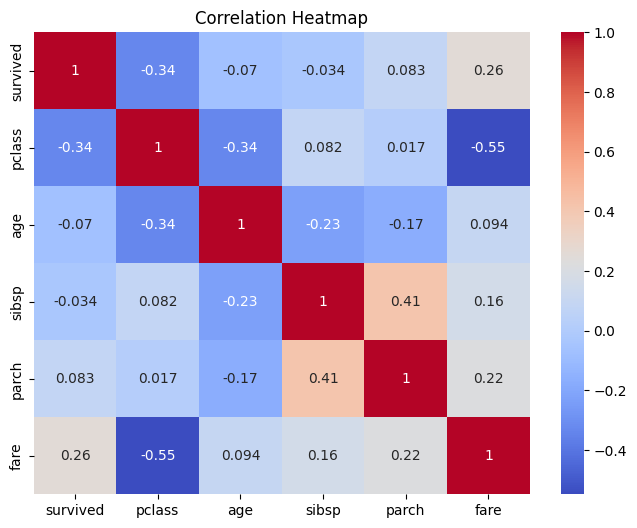

In [196]:
corr_df = df[[
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]]

corr_matrix = corr_df.corr()

# print(corr_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The heatmap shows that pclass and fare have the strongest negative correlation, indicating that passengers in higher classes generally paid higher fares. The positive correlation between sibsp and parch suggests that passengers traveling with siblings or spouses were also more likely to travel with parents or children.


In [197]:
pairs_df = corr_matrix.stack().reset_index()

pairs_df.columns = ["feature1", "feature2", "correlation"]
pairs_df = pairs_df[pairs_df['feature1'] != pairs_df['feature2']]


columns = list(corr_matrix.columns)

# map the index for each column and check the duplicates
pairs_df = pairs_df[
    pairs_df["feature1"].map(columns.index) <
    pairs_df["feature2"].map(columns.index)
]

pairs_df['abs_correlation'] = pairs_df['correlation'].abs()

pairs_df = pairs_df.sort_values("abs_correlation",ascending=False)
top_2 = pairs_df.head(2)
print("Top 2 strongest correlations:")
print(top_2)

Top 2 strongest correlations:
   feature1 feature2  correlation  abs_correlation
11   pclass     fare    -0.548193         0.548193
22    sibsp    parch     0.414542         0.414542


The Top 2 are:
Pclass,Fare and
Sibsp,Parch

The strongest correlation is between pclass and fare. The correlation is negative, indicating that passengers in higher travel classes (lower numerical pclass values) generally paid higher fares.

The second strongest correlation is between sibsp and parch. The positive correlation suggests that passengers traveling with siblings/spouses were also more likely to travel with parents or children.

Multivariate Analysis

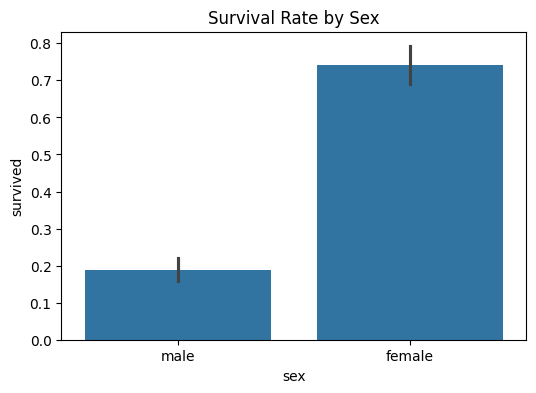

In [198]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='sex', y='survived')
plt.title("Survival Rate by Sex")
plt.savefig("charts/survival_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()

Female passengers had a much higher survival rate than male passengers. This suggests that gender was one of the strongest factors influencing survival, consistent with the "women first" evacuation policy. Male passengers were significantly less likely to survive.

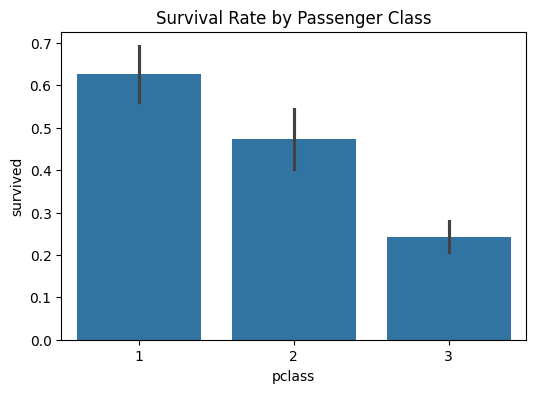

In [199]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='pclass', y='survived')
plt.title("Survival Rate by Passenger Class")
plt.savefig("charts/survival_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

First-class passengers had the highest survival rate, while third-class passengers had the lowest. This indicates that socioeconomic status or cabin location likely influenced access to lifeboats. Passenger class was therefore an important predictor of survival.

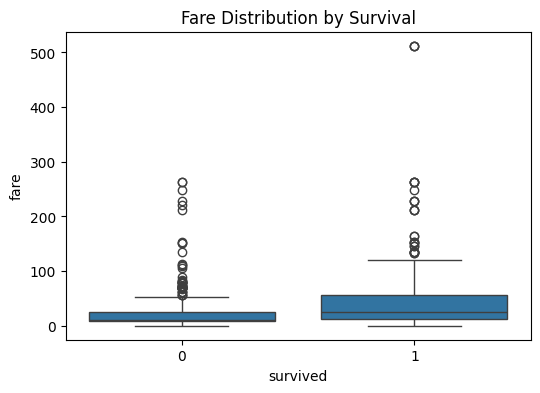

In [200]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='survived', y='fare')
plt.title("Fare Distribution by Survival")
plt.savefig("charts/fare_vs_survival.png", dpi=300, bbox_inches="tight")
plt.show()

Passengers who survived generally paid higher fares than those who did not survive. The higher median fare among survivors reflects that wealthier passengers, who were often in higher classes, had better chances of survival. A few extremely high fares appear as outliers.

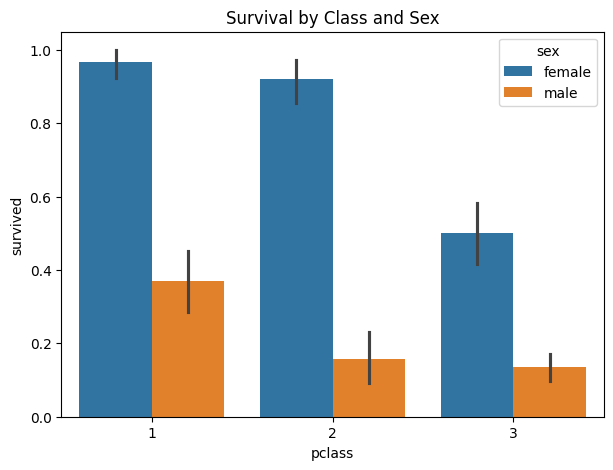

In [201]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='pclass', y='survived', hue='sex')
plt.title("Survival by Class and Sex")
plt.savefig("charts/survival_by_class_and_sex.png", dpi=300, bbox_inches="tight")
plt.show()

Female passengers had higher survival rates than males in every passenger class. First-class women had the highest survival probability, while third-class men had the lowest. This chart shows that both gender and passenger class jointly influenced survival outcomes.

These four charts naturally build the narrative:

Gender mattered → Women survived more often.
Passenger class mattered → First-class passengers survived more often.
Fare reflects wealth/class → Higher-paying passengers had better survival chances.
Gender + class together → First-class women were the safest group, while third-class men were the most vulnerable.

In [202]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
before=df[['age','fare']].copy()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])
print("Before Standardization")
print(before.agg(['mean', 'std']))

print("\nAfter Standardization")
print(df[['age', 'fare']].agg(['mean', 'std']))

df[['age','fare']] = before

Before Standardization
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


The age and fare columns were standardized using z-score normalization. After transformation, both variables have approximately zero mean and unit standard deviation, confirming successful scaling. This step is performed only as an EDA sanity check and will not be reused in the modeling pipeline, where scaling will be fit only on the training data after the train-test split to prevent data leakage.